In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

In [5]:
# load data
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
# inspect the data
df.shape
df.info()
df.isna().sum()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
# clean the data
# Drop constants and ID
df = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], errors='ignore')

# Handle missing Income
df['Income'] = df['Income'].fillna(df['Income'].median())

# Convert date
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Feature engineering
df['Age'] = 2024 - df['Year_Birth']
df['Customer_For'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

df['Total_Spend'] = df[[
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]].sum(axis=1)

df['Total_Purchases'] = df[[
    'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases'
]].sum(axis=1)

df['Children'] = df['Kidhome'] + df['Teenhome']

df['AcceptedCmpTotal'] = df[[
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5'
]].sum(axis=1)

# Clean categories
df['Education'] = df['Education'].replace({
    '2n Cycle': 'Master',
    'Basic': 'Basic',
    'Graduation': 'Graduation',
    'Master': 'Master',
    'PhD': 'PhD'
})

df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Other',
    'YOLO': 'Other'
})

# Remove obvious outliers
df = df[df['Age'] <= 90]
df = df[df['Income'] < 200000]

In [8]:
# check the cleaned set
df.shape
df.head()
df.isna().sum()

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Age                    0
Customer_For           0
Total_Spend            0
Total_Purchases        0
Children               0
AcceptedCmpTotal       0
dtype: int64

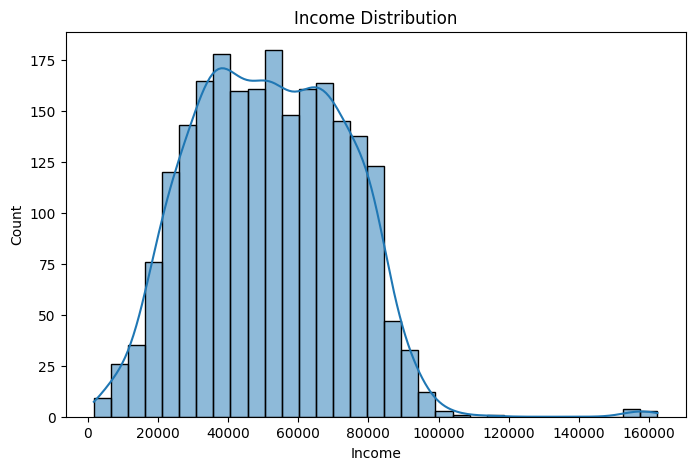

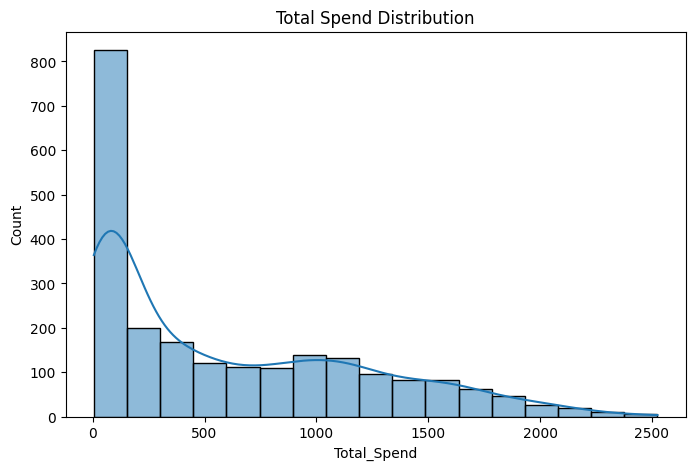

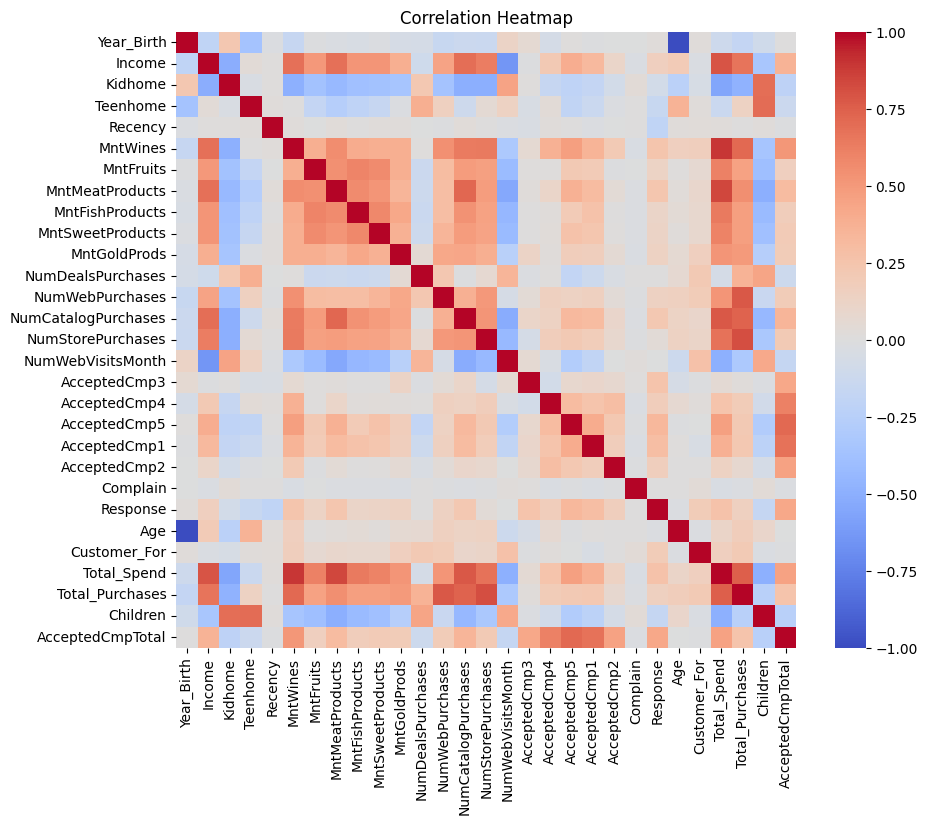

In [9]:
# EDA
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True)
plt.title('Income Distribution')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Total_Spend'], kde=True)
plt.title('Total Spend Distribution')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [10]:
# Prepare for clustering
drop_cols = [
    'Year_Birth', 'Dt_Customer', 'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5'
]

categorical_cols = ['Education', 'Marital_Status']
numeric_cols = [c for c in df.columns if c not in categorical_cols + drop_cols + ['Cluster']]

X = df[categorical_cols + numeric_cols]

In [11]:
# build preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

X_scaled = preprocessor.fit_transform(X)
X_scaled.shape

(2236, 30)

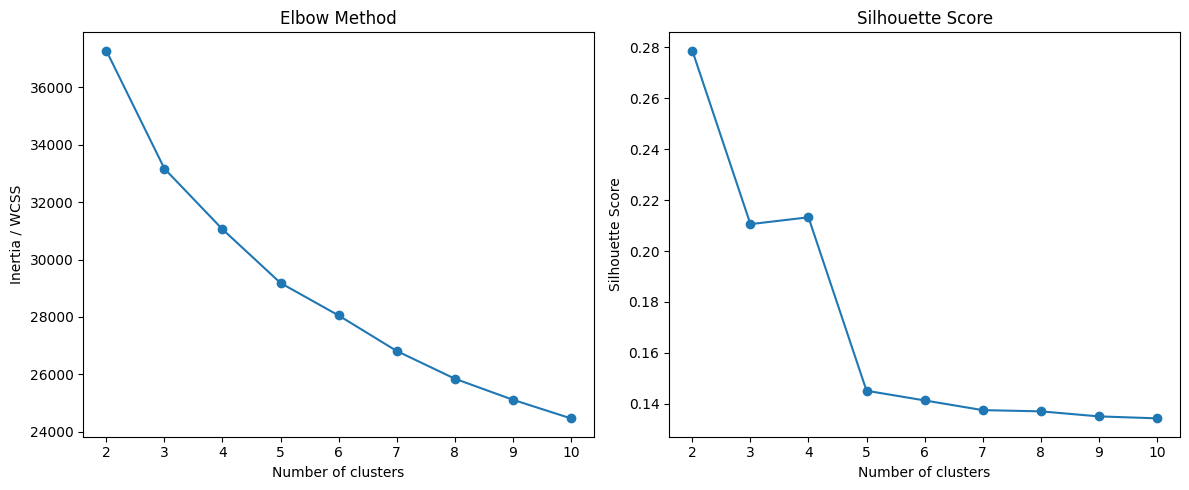

In [12]:
# K means: elbow method and silhouette score
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia / WCSS')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

In [17]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette:', silhouette_score(X_scaled, df['Cluster']))
print('Davies-Bouldin:', davies_bouldin_score(X_scaled, df['Cluster']))
print('Calinski-Harabasz:', calinski_harabasz_score(X_scaled, df['Cluster']))

Silhouette: 0.27869418347478647
Davies-Bouldin: 1.5204184219360828
Calinski-Harabasz: 880.2592406506761


In [18]:
# interpret k means cluster
cluster_summary = df.groupby('Cluster')[numeric_cols].mean().round(2)
cluster_summary

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Customer_For,Total_Spend,Total_Purchases,Children,AcceptedCmpTotal
Cluster,,,,,,,,,,,,,,,,,,,,,
0,38563.35,0.71,0.55,48.85,91.52,6.48,35.47,9.42,6.40,21.61,...,0.83,3.85,6.4,0.01,53.69,336.44,170.90,10.03,1.26,0.10
1,70720.60,0.07,0.44,49.49,602.14,54.02,351.33,76.95,56.07,75.34,...,5.23,8.53,3.8,0.01,57.08,378.08,1215.85,21.66,0.51,0.57


In [ ]:
# categorical breakdown
for col in categorical_cols:
    print(df.groupby('Cluster')[col].value_counts(normalize=True).unstack().round(2))

Education  Basic  Graduation  Master   PhD
Cluster                                   
0           0.04        0.49    0.27  0.20
1           0.00        0.52    0.24  0.24
Marital_Status  Divorced  Married  Other  Single  Together  Widow
Cluster                                                          
0                   0.10     0.39    0.0    0.22      0.26   0.03
1                   0.11     0.37    0.0    0.21      0.25   0.05


In [20]:
# campaign response by cluster
df.groupby('Cluster')['Response'].mean().round(3)

Cluster
0    0.095
1    0.226
Name: Response, dtype: float64

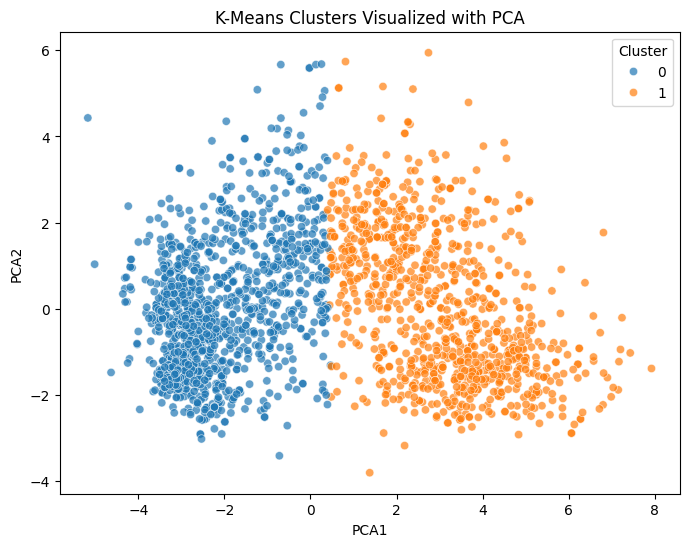

In [21]:
# visualize clusters with pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

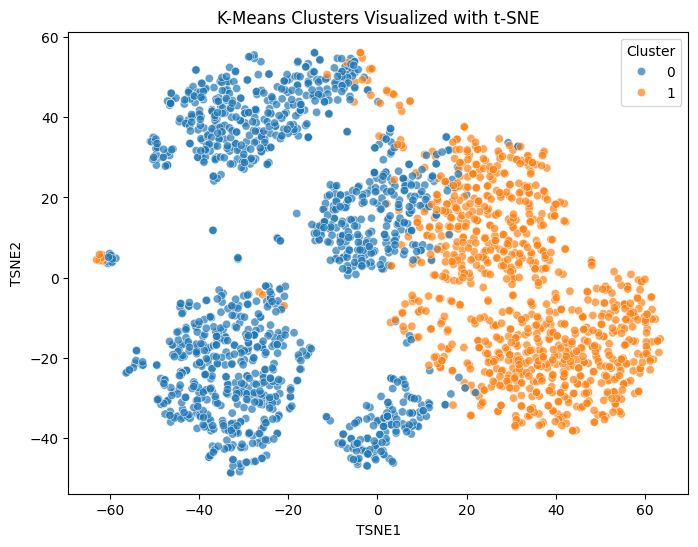

In [23]:
#t- SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

df['TSNE1'] = X_tsne[:, 0]
df['TSNE2'] = X_tsne[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title('K-Means Clusters Visualized with t-SNE')
plt.show()

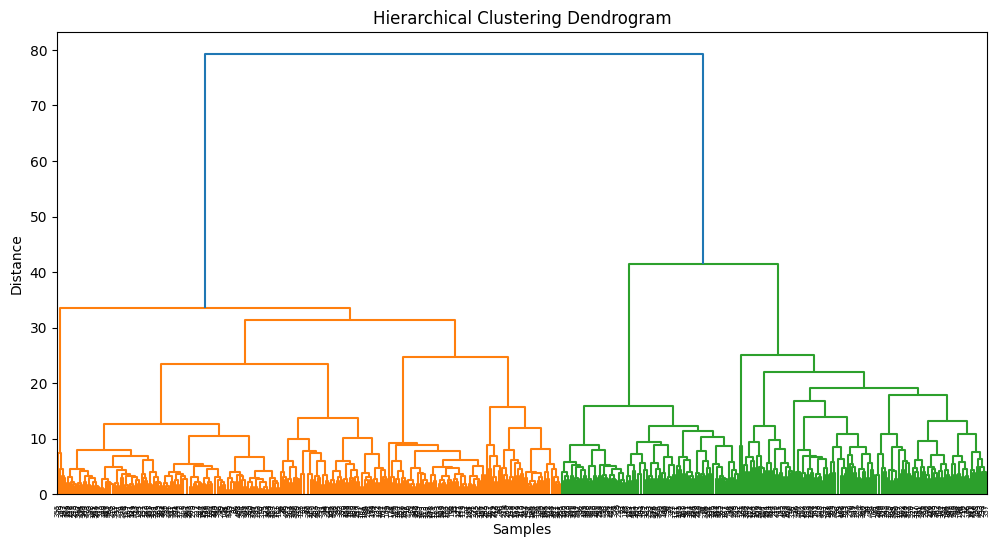

In [24]:
# hierarchical clustering
plt.figure(figsize=(12,6))
dendrogram(linkage(X_scaled[:500], method='ward'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [47]:
# DBscan
dbscan = DBSCAN(eps=2.0, min_samples=8)
df['Cluster_DB'] = dbscan.fit_predict(X_scaled)

print(df['Cluster_DB'].value_counts())

Cluster_DB
-1    1465
 1     392
 0     247
 6      50
 4      25
 2      23
 5      20
 3       8
 7       6
Name: count, dtype: int64


In [48]:
labels_db = df['Cluster_DB']
if len(set(labels_db)) > 1 and -1 in set(labels_db):
    mask = labels_db != -1
    print('DBSCAN Silhouette:', silhouette_score(X_scaled[mask], labels_db[mask]))
elif len(set(labels_db)) > 1:
    print('DBSCAN Silhouette:', silhouette_score(X_scaled, labels_db))

DBSCAN Silhouette: 0.14911275351780823


In [49]:
# Gaussian mixture model
gmm = GaussianMixture(n_components=4, random_state=42)
df['Cluster_GMM'] = gmm.fit_predict(X_scaled)

print('GMM Silhouette:', silhouette_score(X_scaled, df['Cluster_GMM']))

GMM Silhouette: 0.22189322799727754


In [53]:
# compare models
def evaluate_model(X, labels, name):
    if len(set(labels)) > 1:
        print(f"{name}")
        print("  Silhouette:", round(silhouette_score(X, labels), 3))
        print("  Davies-Bouldin:", round(davies_bouldin_score(X, labels), 3))
        print("  Calinski-Harabasz:", round(calinski_harabasz_score(X, labels), 3))
    else:
        print(f"{name}: only one cluster")

evaluate_model(X_scaled, df['Cluster'], 'K-Means')
evaluate_model(X_scaled, df['Cluster_DB'], 'Hierarchical')
evaluate_model(X_scaled, df['Cluster_GMM'], 'GMM')

K-Means
  Silhouette: 0.279
  Davies-Bouldin: 1.52
  Calinski-Harabasz: 880.259
Hierarchical
  Silhouette: -0.048
  Davies-Bouldin: 1.726
  Calinski-Harabasz: 76.402
GMM
  Silhouette: 0.222
  Davies-Bouldin: 2.538
  Calinski-Harabasz: 303.784


In [54]:
# Average numeric profile per cluster
cluster_summary = df.groupby('Cluster')[numeric_cols].mean().round(2)
print(cluster_summary)

# Categorical profile
for col in ['Education', 'Marital_Status']:
    print(f"\n{col} by Cluster:")
    print(df.groupby('Cluster')[col].value_counts(normalize=True).unstack().round(2))

# Campaign response rate
print("\nResponse Rate by Cluster:")
print(df.groupby('Cluster')['Response'].mean().round(3))

# Cluster sizes
print("\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())

           Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
Cluster                                                              
0        38563.35     0.71      0.55    48.85     91.52       6.48   
1        70720.60     0.07      0.44    49.49    602.14      54.02   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
Cluster                                                                     
0                  35.47             9.42              6.40         21.61   
1                 351.33            76.95             56.07         75.34   

         ...  NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
Cluster  ...                                                              
0        ...                 0.83               3.85                6.4   
1        ...                 5.23               8.53                3.8   

         Complain    Age  Customer_For  Total_Spend  Total_Purchases  \
Cluster                              

## CONCLUSION
## Best Model: K-Means (k = 2)

Based on your evaluation metrics, **K-Means is the best model**.

| Model | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | Result |
|---|---:|---:|---:|---|
| **K-Means** | **0.279** | **1.520** | **880.259** | **Best** |
| Hierarchical | -0.048 | 1.726 | 76.402 | Poor |
| GMM | 0.222 | 2.538 | 303.784 | Worse than K-Means |

### What the values mean

- **Silhouette Score = 0.279**  
  Higher is better, range is -1 to 1.  
  0.279 means the clusters are **moderately separated**. Not perfect, but the best among your models.

- **Davies-Bouldin = 1.52**  
  Lower is better.  
  1.52 is acceptable and better than Hierarchical and GMM.

- **Calinski-Harabasz = 880.259**  
  Higher is better.  
  880.259 is much higher than the other models, meaning K-Means has stronger between-cluster separation.

So: **K-Means with 2 clusters is the final model.**

---

## Cluster Values

Your K-Means output produced **2 clusters**:

| Feature | Cluster 0 | Cluster 1 |
|---|---:|---:|
| Customers | 1,305 | 931 |
| Income | 38,563 | 70,721 |
| Total Spend | 170.90 | 1,215.85 |
| Total Purchases | 10.03 | 21.66 |
| Children | 1.26 | 0.51 |
| Kidhome | 0.71 | 0.07 |
| Teenhome | 0.55 | 0.44 |
| Age | 53.69 | 57.08 |
| Web Visits / Month | 6.40 | 3.80 |
| Catalog Purchases | 0.83 | 5.23 |
| Store Purchases | 3.85 | 8.53 |
| MntWines | 91.52 | 602.14 |
| MntMeatProducts | 35.47 | 351.33 |
| MntGoldProds | 21.61 | 75.34 |
| Accepted Campaigns | 0.10 | 0.57 |

---

## Cluster 0 — Budget-Conscious Families

- **1,305 customers — 58.4% of the base**
- Lower income: **38,563**
- Low total spend: **170.90**
- More children: **1.26 average**
- High web visits: **6.4/month**
- Low catalog purchases: **0.83**
- Low campaign acceptance: **0.10**

**Meaning:**  
These are mostly family-oriented, price-sensitive customers. They browse online often but buy little. They are not the main revenue drivers.

**Strategy:**  
Use discounts, bundles, family offers, and retargeting ads. Focus on essentials rather than premium products.

---

## Cluster 1 — Premium Affluent Customers

- **931 customers — 41.6% of the base**
- High income: **70,721**
- Very high total spend: **1,215.85**
- Fewer children: **0.51 average**
- Lower web visits: **3.8/month**
- High catalog purchases: **5.23**
- High store purchases: **8.53**
- High campaign acceptance: **0.57**

**Meaning:**  
These are the high-value customers. They earn more, spend much more, buy through catalogs and stores, and respond well to campaigns. They generate most of the revenue.

**Strategy:**  
Retain them with loyalty programs, VIP offers, premium product recommendations, catalogs, and exclusive campaigns.

---

## Final Business Summary

- **Cluster 1 is the most valuable segment.**  
  Only 41.6% of customers, but they spend **7.1× more** than Cluster 0.

- **Cluster 0 is the largest but lowest-value segment.**  
  They need discount-driven and family-focused marketing.

- **K-Means with k=2 is the best model** because it has the best Silhouette, best Davies-Bouldin, and best Calinski-Harabasz scores.

**Conclusion:**  
Use **K-Means (k=2)** for customer segmentation. Focus retention and premium marketing on **Cluster 1**, and use discounts/retargeting to convert **Cluster 0**.